# Rahil Ghanem 
# Group 07
# **Assignment 6-2: Sarsa, Q-Learning and Expected Sarsa**

Welcome to Assignment 6-2. In this notebook, you will:

1. Implement Sarsa with $\epsilon$-greedy action selection
2. Implement Q-Learning with $\epsilon$-greedy action selection
3. Implement Expected Sarsa with $\epsilon$-greedy action selection
4. Investigate how these two algorithms behave on Cliff World (described on page 132 of the textbook)

We will provide you with the environment and infrastructure to run an experiment (called the experiment program in RL-Glue). This notebook will provide all the code you need to run your experiment and visualise learning performance.

## Packages

You will need the following libraries for this assignment. We are using:
1. numpy: the fundamental package for scientific computing with Python.
2. scipy: a Python library for scientific and technical computing.
3. matplotlib: library for plotting graphs in Python.
4. RL-Glue: library for reinforcement learning experiments.

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import sem

from env.rl_glue import RLGlue
from env.agent import BaseAgent
from env import cliffworld_env

In [3]:
plt.rcParams.update({'font.size': 15})
plt.rcParams.update({'figure.figsize': [10,5]})

# Sarsa

In this section you will implement and test a Sarsa agent with $\epsilon$-greedy action selection (Section 6.4 in the textbook). 

### Implementation

Your job is to implement the updates in the methods agent_step and agent_end. We provide detailed comments in each method describing what your code should do.

In [4]:
class SarsaAgent(BaseAgent):
    def agent_init(self, agent_init_info):
        """Setup for the agent called when the experiment first starts.
        
        Args:
        agent_init_info (dict), the parameters used to initialize the agent. The dictionary contains:
        {
            num_states (int): The number of states,
            num_actions (int): The number of actions,
            epsilon (float): The epsilon parameter for exploration,
            step_size (float): The step-size,
            discount (float): The discount factor,
        }
        
        """
        # Store the parameters provided in agent_init_info.
        self.num_actions = agent_init_info["num_actions"]
        self.num_states = agent_init_info["num_states"]
        self.epsilon = agent_init_info["epsilon"]
        self.step_size = agent_init_info["step_size"]
        self.discount = agent_init_info["discount"]
        self.rand_generator = np.random.RandomState(agent_info["seed"])
        
        # Create an array for action-value estimates and initialize it to zero.
        self.q = np.zeros((self.num_states, self.num_actions)) # The array of action-value estimates.

        
    def agent_start(self, observation):
        """The first method called when the episode starts, called after
        the environment starts.
        Args:
            observation (int): the state observation from the
                environment's evn_start function.
        Returns:
            action (int): the first action the agent takes.
        """
        
        # Choose action using epsilon greedy.
        # YOUR CODE HERE
        state = observation
        current_q = self.q[state,:]
        if self.rand_generator.rand() < self.epsilon:
            action = self.rand_generator.randint(self.num_actions)  # random action
        else:
            action = self.argmax(current_q)  # greedy action

        self.prev_state = state
        self.prev_action = action

        return action
    
    def agent_step(self, reward, observation):
        """A step taken by the agent.
        Args:
            reward (float): the reward received for taking the last action taken
            observation (int): the state observation from the
                environment's step based on where the agent ended up after the
                last step.
        Returns:
            action (int): the action the agent is taking.
        """
        
        # Choose action using epsilon greedy.
        state = observation
        current_q = self.q[state,:]
        if self.rand_generator.rand() < self.epsilon:
            action = self.rand_generator.randint(self.num_actions)
        else:
            action = self.argmax(current_q)
        
        # Perform an update
        # YOUR CODE HERE
        # Sarsa update: Q(S,A) <- Q(S,A) + alpha * [R + gamma * Q(S',A') - Q(S,A)]
        S = self.prev_state
        A = self.prev_action
        self.q[S, A] = self.q[S, A] + self.step_size * (reward + self.discount * self.q[state, action] - self.q[S, A])
        
        self.prev_state = state
        self.prev_action = action

        return action
    
    def agent_end(self, reward):
        """Run when the agent terminates.
        Args:
            reward (float): the reward the agent received for entering the
                terminal state.
        """
        # Perform the last update in the episode
        # YOUR CODE HERE
        # Sarsa terminal update: Q(S,A) <- Q(S,A) + alpha * [R + 0 - Q(S,A)]
        # (no next state, so next Q value = 0)
        S = self.prev_state
        A = self.prev_action
        self.q[S, A] = self.q[S, A] + self.step_size * (reward - self.q[S, A])
        
    def argmax(self, q_values):
        """argmax with random tie-breaking
        Args:
            q_values (Numpy array): the array of action-values
        Returns:
            action (int): an action with the highest value
        """
        top = float("-inf")
        ties = []

        for i in range(len(q_values)):
            if q_values[i] > top:
                top = q_values[i]
                ties = []

            if q_values[i] == top:
                ties.append(i)

        return self.rand_generator.choice(ties)

## Q-Learning

In this section you will implement and test a Q-Learning agent with $\epsilon$-greedy action selection (Section 6.5 in the textbook). 

### Implementation

Your job is to implement the updates in the methods agent_step and agent_end. We provide detailed comments in each method describing what your code should do.

In [5]:
class QLearningAgent(BaseAgent):
    def agent_init(self, agent_init_info):
        """Setup for the agent called when the experiment first starts.
        
        Args:
        agent_init_info (dict), the parameters used to initialize the agent. The dictionary contains:
        {
            num_states (int): The number of states,
            num_actions (int): The number of actions,
            epsilon (float): The epsilon parameter for exploration,
            step_size (float): The step-size,
            discount (float): The discount factor,
        }
        
        """
        # Store the parameters provided in agent_init_info.
        self.num_actions = agent_init_info["num_actions"]
        self.num_states = agent_init_info["num_states"]
        self.epsilon = agent_init_info["epsilon"]
        self.step_size = agent_init_info["step_size"]
        self.discount = agent_init_info["discount"]
        self.rand_generator = np.random.RandomState(agent_info["seed"])
        
        # Create an array for action-value estimates and initialize it to zero.
        self.q = np.zeros((self.num_states, self.num_actions)) # The array of action-value estimates.

        
    def agent_start(self, observation):
        """The first method called when the episode starts, called after
        the environment starts.
        Args:
            observation (int): the state observation from the
                environment's evn_start function.
        Returns:
            action (int): the first action the agent takes.
        """
        
        # Choose action using epsilon greedy.
        # YOUR CODE HERE
        state = observation
        current_q = self.q[state,:]
        if self.rand_generator.rand() < self.epsilon:
            action = self.rand_generator.randint(self.num_actions)  # random action
        else:
            action = self.argmax(current_q)  # greedy action

        self.prev_state = state
        self.prev_action = action

        return action
    
    def agent_step(self, reward, observation):
        """A step taken by the agent.
        Args:
            reward (float): the reward received for taking the last action taken
            observation (int): the state observation from the
                environment's step based on where the agent ended up after the
                last step.
        Returns:
            action (int): the action the agent is taking.
        """
        
        # Choose action using epsilon greedy.
        # YOUR CODE HERE
        state = observation
        current_q = self.q[state,:]
        if self.rand_generator.rand() < self.epsilon:
            action = self.rand_generator.randint(self.num_actions)
        else:
            action = self.argmax(current_q)
        
        # Perform an update
        # YOUR CODE HERE
        # Q-learning update: Q(S,A) <- Q(S,A) + alpha * [R + gamma * max_a Q(S',a) - Q(S,A)]
        # Key difference from Sarsa: use max Q(S',a) instead of Q(S',A')
        S = self.prev_state
        A = self.prev_action
        self.q[S, A] = self.q[S, A] + self.step_size * (reward + self.discount * np.max(self.q[state,:]) - self.q[S, A])
        
        self.prev_state = state
        self.prev_action = action

        return action
    
    def agent_end(self, reward):
        """Run when the agent terminates.
        Args:
            reward (float): the reward the agent received for entering the
                terminal state.
        """
        # Perform the last update in the episode
        # YOUR CODE HERE
        # Q-learning terminal update: Q(S,A) <- Q(S,A) + alpha * [R + 0 - Q(S,A)]
        S = self.prev_state
        A = self.prev_action
        self.q[S, A] = self.q[S, A] + self.step_size * (reward - self.q[S, A])

        
    def argmax(self, q_values):
        """argmax with random tie-breaking
        Args:
            q_values (Numpy array): the array of action-values
        Returns:
            action (int): an action with the highest value
        """
        top = float("-inf")
        ties = []

        for i in range(len(q_values)):
            if q_values[i] > top:
                top = q_values[i]
                ties = []

            if q_values[i] == top:
                ties.append(i)

        return self.rand_generator.choice(ties)

# Expected Sarsa

In this section you will implement an Expected Sarsa agent with $\epsilon$-greedy action selection (Section 6.6 in the textbook). 

### Implementation

Your job is to implement the updates in the methods agent_step and agent_end. We provide detailed comments in each method describing what your code should do.

In [6]:
class ExpectedSarsaAgent(BaseAgent):
    def agent_init(self, agent_init_info):
        """Setup for the agent called when the experiment first starts.
        
        Args:
        agent_init_info (dict), the parameters used to initialize the agent. The dictionary contains:
        {
            num_states (int): The number of states,
            num_actions (int): The number of actions,
            epsilon (float): The epsilon parameter for exploration,
            step_size (float): The step-size,
            discount (float): The discount factor,
        }
        
        """
        # Store the parameters provided in agent_init_info.
        self.num_actions = agent_init_info["num_actions"]
        self.num_states = agent_init_info["num_states"]
        self.epsilon = agent_init_info["epsilon"]
        self.step_size = agent_init_info["step_size"]
        self.discount = agent_init_info["discount"]
        self.rand_generator = np.random.RandomState(agent_info["seed"])
        
        # Create an array for action-value estimates and initialize it to zero.
        self.q = np.zeros((self.num_states, self.num_actions)) # The array of action-value estimates.

        
    def agent_start(self, observation):
        """The first method called when the episode starts, called after
        the environment starts.
        Args:
            observation (int): the state observation from the
                environment's evn_start function.
        Returns:
            action (int): the first action the agent takes.
        """
        
        # Choose action using epsilon greedy.
        # YOUR CODE HERE
        state = observation
        current_q = self.q[state,:]
        if self.rand_generator.rand() < self.epsilon:
            action = self.rand_generator.randint(self.num_actions)  # random action
        else:
            action = self.argmax(current_q)  # greedy action
        
        self.prev_state = state
        self.prev_action = action
        
        return action
    
    def agent_step(self, reward, observation):
        """A step taken by the agent.
        Args:
            reward (float): the reward received for taking the last action taken
            observation (int): the state observation from the
                environment's step based on where the agent ended up after the
                last step.
        Returns:
            action (int): the action the agent is taking.
        """
        
        # Choose action using epsilon greedy.
        # YOUR CODE HERE
        state = observation
        current_q = self.q[state,:]
        if self.rand_generator.rand() < self.epsilon:
            action = self.rand_generator.randint(self.num_actions)
        else:
            action = self.argmax(current_q)
        
        # Perform an update
        # YOUR CODE HERE
        # Expected Sarsa update: Q(S,A) <- Q(S,A) + alpha * [R + gamma * sum_a pi(a|S') * Q(S',a) - Q(S,A)]
        # Under epsilon-greedy policy:
        #   - Greedy action gets probability (1 - epsilon) + epsilon/num_actions
        #   - Non-greedy actions each get probability epsilon/num_actions
        policy = np.ones(self.num_actions) * self.epsilon / self.num_actions  # non-greedy prob
        best_action = self.argmax(self.q[state,:])
        policy[best_action] = (1 - self.epsilon) + self.epsilon / self.num_actions  # greedy prob
        
        expected_value = 0
        for a in range(self.num_actions):
            expected_value = expected_value + policy[a] * self.q[state, a]
            
        S = self.prev_state
        A = self.prev_action      
        self.q[S, A] = self.q[S, A] + self.step_size * (reward + self.discount * expected_value - self.q[S, A])
        
        self.prev_state = state
        self.prev_action = action

        return action
    
    def agent_end(self, reward):
        """Run when the agent terminates.
        Args:
            reward (float): the reward the agent received for entering the
                terminal state.
        """
        # Perform the last update in the episode
        # YOUR CODE HERE
        # Terminal update: Q(S,A) <- Q(S,A) + alpha * [R + 0 - Q(S,A)]
        # (terminal state has no next state, so expected value = 0)
        S = self.prev_state
        A = self.prev_action
        self.q[S, A] = self.q[S, A] + self.step_size * (reward - self.q[S, A])
        
    def argmax(self, q_values):
        """argmax with random tie-breaking
        Args:
            q_values (Numpy array): the array of action-values
        Returns:
            action (int): an action with the highest value
        """
        top = float("-inf")
        ties = []

        for i in range(len(q_values)):
            if q_values[i] > top:
                top = q_values[i]
                ties = []

            if q_values[i] == top:
                ties.append(i)

        return self.rand_generator.choice(ties)

# Solving the Cliff World

We described the Cliff World environment in the prvious lab assignement. This is an undiscounted episodic task and thus we set $\gamma=1$. The agent starts in the bottom left corner of the gridworld below and takes actions that move it in the four directions. Actions that would move the agent off of the cliff incur a reward of -100 and send the agent back to the start state. The reward for all other transitions is -1. An episode terminates when the agent reaches the bottom right corner. 

<img src="img/cliffworld.png" alt="Drawing" style="width: 600px;"/>


Using the experiment program in the cell below we now compare the agents on the Cliff World environment and plot the sum of rewards during each episode for the two agents.

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:28<00:00,  3.56it/s]


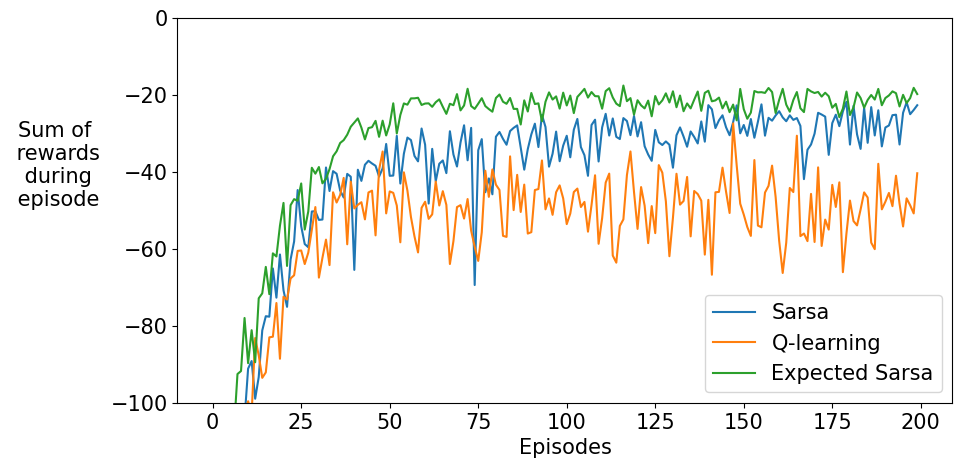

In [7]:
np.random.seed(0)

agents = {
    "Sarsa": SarsaAgent,
    "Q-learning": QLearningAgent,
    "Expected Sarsa": ExpectedSarsaAgent
}

env = cliffworld_env.Environment

all_reward_sums = {} # Contains sum of rewards during episode
all_state_visits = {} # Contains state visit counts during the last 10 episodes
agent_info = {"num_actions": 4, "num_states": 48, "epsilon": 0.1, "step_size": 0.5, "discount": 1.0}
env_info = {}
num_runs = 100 # The number of runs
num_episodes = 200 # The number of episodes in each run

for algorithm in ["Sarsa", "Q-learning", "Expected Sarsa"]:
    all_reward_sums[algorithm] = []
    all_state_visits[algorithm] = []
    for run in tqdm(range(num_runs)):
        agent_info["seed"] = run
        rl_glue = RLGlue(env, agents[algorithm])
        rl_glue.rl_init(agent_info, env_info)

        reward_sums = []
        state_visits = np.zeros(48)
        for episode in range(num_episodes):
            if episode < num_episodes - 10:
                # Runs an episode
                rl_glue.rl_episode(10000) 
            else: 
                # Runs an episode while keeping track of visited states
                # YOUR CODE HERE
                state, action = rl_glue.rl_start()
                state_visits[state] = state_visits[state] + 1
                is_terminal = False
                while not is_terminal:
                    reward, state, action, is_terminal = rl_glue.rl_step()
                    state_visits[state] = state_visits[state] + 1
                
            reward_sums.append(rl_glue.rl_return())
            
        all_reward_sums[algorithm].append(reward_sums)
        all_state_visits[algorithm].append(state_visits)

# plot results
for algorithm in ["Sarsa", "Q-learning", "Expected Sarsa"]:
    plt.plot(np.mean(all_reward_sums[algorithm], axis=0), label=algorithm)
plt.xlabel("Episodes")
plt.ylabel("Sum of\n rewards\n during\n episode",rotation=0, labelpad=40)
plt.ylim(-100,0)
plt.legend()
plt.show()

To see why these two agents behave differently, let's inspect the states they visit most. Run the cell below to generate plots showing the number of timesteps that the agents spent in each state over the last 10 episodes.

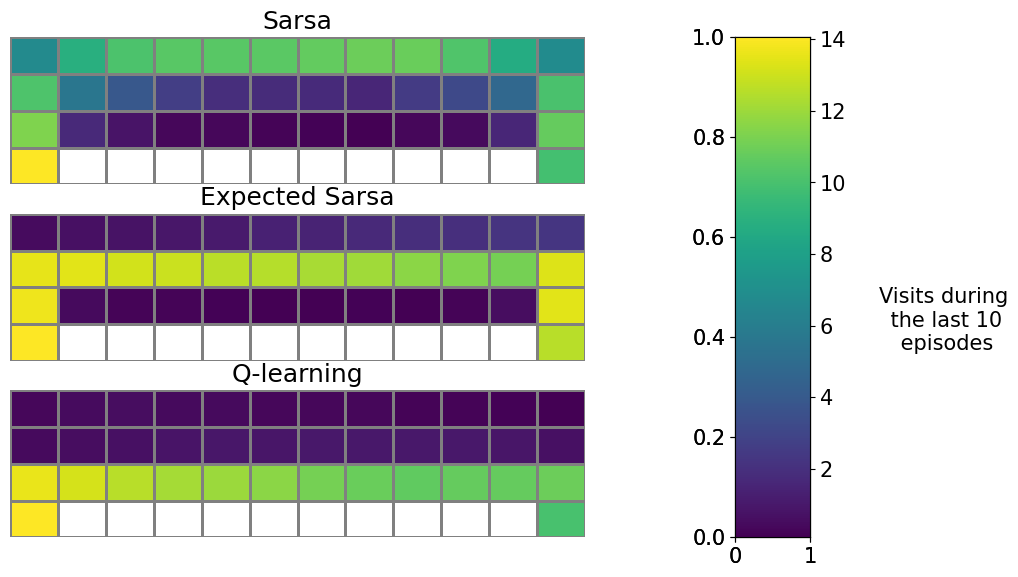

In [8]:
for algorithm, position in [("Sarsa", 311), ("Expected Sarsa", 312), ("Q-learning", 313)]:
    plt.subplot(position)
    average_state_visits = np.array(all_state_visits[algorithm]).mean(axis=0)
    grid_state_visits = average_state_visits.reshape((4,12))
    grid_state_visits[0,1:-1] = np.nan
    plt.pcolormesh(grid_state_visits, edgecolors='gray', linewidth=2)
    plt.title(algorithm)
    plt.axis('off')
    cm = plt.get_cmap()
    cm.set_bad('gray')

    plt.subplots_adjust(bottom=0.0, right=0.7, top=1.0)
    cax = plt.axes([0.85, 0.0, 0.075, 1.])
    
cbar = plt.colorbar(cax=cax)
cbar.ax.set_ylabel("Visits during\n the last 10\n episodes", rotation=0, labelpad=70)
plt.show()

**Question:**

Based on the obtained visualizations , what insights can you draw from comparing the performance of Sarsa, Q-learning, and Expected Sarsa algorithms on the cliff-walking problem?

**Answer:**

Q-learning learns the optimal but risky path, giving the highest rewards by following the shortest route near the cliff. Sarsa, on the other hand, learns a safer path, resulting in lower rewards but avoiding the cliff by taking a detour. Expected Sarsa lies between the two, balancing performance and safety.

### Key Points
- Q-learning ignores exploration (uses `max Q(s', a)`) → risky but optimal  
- Sarsa considers actual actions (uses `Q(s', a')`) → safer  
- Expected Sarsa balances between them  

 

# Evaluating Step-Size Impact on Agent Performance

Previously we used a fixed step-size of 0.5 for the agents. What happens with other step-sizes? Does this difference in performance persist?

In the next experiment we will try 10 different step-sizes from 0.1 to 1.0 and compare the sum of rewards per episode averaged over the first 100 episodes (similar to the interim performance curves in Figure 6.3 of the textbook). Shaded regions show standard errors.

100%|██████████| 900/900 [02:29<00:00,  6.02it/s]


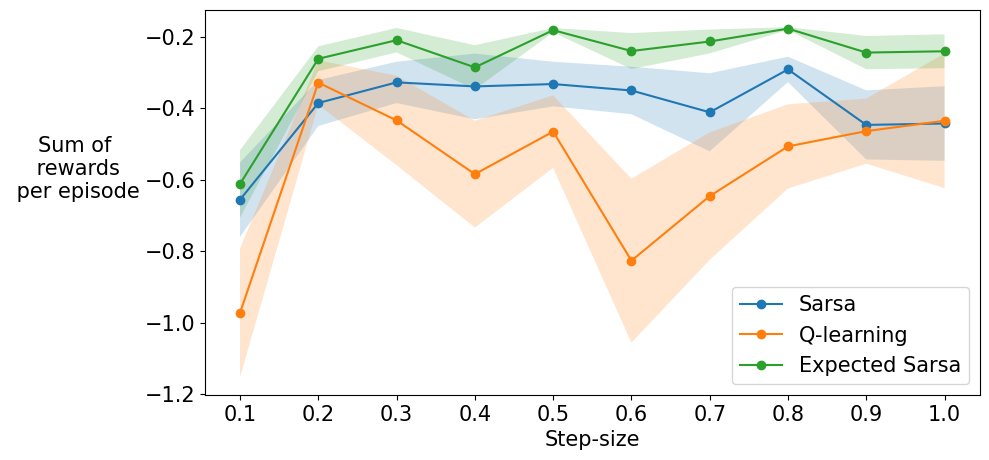

In [9]:
from itertools import product

agents = {
    "Sarsa": SarsaAgent,
    "Q-learning": QLearningAgent,
    "Expected Sarsa": ExpectedSarsaAgent
}

env = cliffworld_env.Environment

all_reward_sums = {}
step_sizes = np.linspace(0.1,1.0,10)
agent_info = {"num_actions": 4, "num_states": 48, "epsilon": 0.1, "discount": 1.0}
env_info = {}
num_runs = 30
num_episodes = 100
all_reward_sums = {}

algorithms = ["Sarsa", "Q-learning", "Expected Sarsa"]
cross_product = list(product(algorithms, step_sizes, range(num_runs)))
for algorithm, step_size, run in tqdm(cross_product):
    if (algorithm, step_size) not in all_reward_sums:
        all_reward_sums[(algorithm, step_size)] = []

    agent_info["step_size"] = step_size
    agent_info["seed"] = run
    rl_glue = RLGlue(env, agents[algorithm])
    rl_glue.rl_init(agent_info, env_info)

    last_episode_total_reward = 0
    for episode in range(num_episodes):
        rl_glue.rl_episode(0)
    all_reward_sums[(algorithm, step_size)].append(rl_glue.rl_return()/num_episodes)
        

for algorithm in ["Sarsa", "Q-learning", "Expected Sarsa"]:
    algorithm_means = np.array([np.mean(all_reward_sums[(algorithm, step_size)]) for step_size in step_sizes])
    algorithm_stds = np.array([sem(all_reward_sums[(algorithm, step_size)]) for step_size in step_sizes])
    plt.plot(step_sizes, algorithm_means, marker='o', linestyle='solid', label=algorithm)
    plt.fill_between(step_sizes, algorithm_means + algorithm_stds, algorithm_means - algorithm_stds, alpha=0.2)

plt.legend()
plt.xlabel("Step-size")
plt.ylabel("Sum of\n rewards\n per episode",rotation=0, labelpad=50)
plt.xticks(step_sizes)
plt.show()

The same experiment as previous considering the sum of rewards per episode averaged over the first 1000 episodes (similar to the interim performance curves in Figure 6.4 of the textbook).

100%|██████████| 900/900 [12:33<00:00,  1.19it/s]


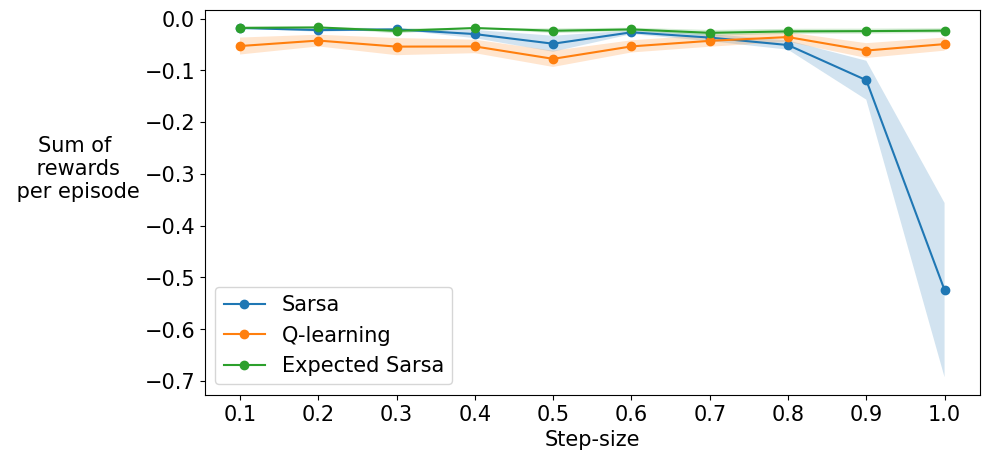

In [10]:
from itertools import product

agents = {
    "Sarsa": SarsaAgent,
    "Q-learning": QLearningAgent,
    "Expected Sarsa": ExpectedSarsaAgent
}

env = cliffworld_env.Environment

all_reward_sums = {}
step_sizes = np.linspace(0.1,1.0,10)
agent_info = {"num_actions": 4, "num_states": 48, "epsilon": 0.1, "discount": 1.0}
env_info = {}
num_runs = 30
num_episodes = 1000
all_reward_sums = {}

algorithms = ["Sarsa", "Q-learning", "Expected Sarsa"]
cross_product = list(product(algorithms, step_sizes, range(num_runs)))
for algorithm, step_size, run in tqdm(cross_product):
    if (algorithm, step_size) not in all_reward_sums:
        all_reward_sums[(algorithm, step_size)] = []

    agent_info["step_size"] = step_size
    agent_info["seed"] = run
    rl_glue = RLGlue(env, agents[algorithm])
    rl_glue.rl_init(agent_info, env_info)

    last_episode_total_reward = 0
    for episode in range(num_episodes):
        rl_glue.rl_episode(0)
    all_reward_sums[(algorithm, step_size)].append(rl_glue.rl_return()/num_episodes)
        

for algorithm in ["Sarsa", "Q-learning", "Expected Sarsa"]:
    algorithm_means = np.array([np.mean(all_reward_sums[(algorithm, step_size)]) for step_size in step_sizes])
    algorithm_stds = np.array([sem(all_reward_sums[(algorithm, step_size)]) for step_size in step_sizes])
    plt.plot(step_sizes, algorithm_means, marker='o', linestyle='solid', label=algorithm)
    plt.fill_between(step_sizes, algorithm_means + algorithm_stds, algorithm_means - algorithm_stds, alpha=0.2)

plt.legend()
plt.xlabel("Step-size")
plt.ylabel("Sum of\n rewards\n per episode",rotation=0, labelpad=50)
plt.xticks(step_sizes)
plt.show()

**Question:**

What does the experiment comparing Expected Sarsa, Sarsa, and Q-learning on the Cliff World task reveal about their relative performance and sensitivity to the step-size parameter $\alpha$?

**Answer:**

In early learning (100 episodes), Q-learning performs best with larger step-sizes (0.5–1.0) but is sensitive to tuning. Sarsa is more stable and works well across different step-sizes, while Expected Sarsa shows intermediate behavior and performs better than Q-learning when step-sizes are small.

In long-term learning (1000 episodes), all three methods converge to similar performance. Q-learning benefits from faster early learning, Sarsa remains stable and consistent, and Expected Sarsa balances between the two.

### Key Points
- Q-learning is sensitive to step-size and needs tuning  
- Sarsa is robust and consistent  
- Expected Sarsa provides a balance  



Congratulations! You’ve successfully completed this lab assignment. Along the way, you have:

- Implemented SARSA with $\epsilon$-greedy action selection  
- Implemented Q-Learning with $\epsilon$-greedy action selection  
- Implemented Expected SARSA with $\epsilon$-greedy action selection  
- Explored and compared the behavior of these algorithms in the Cliff World environment